# Final held-out test evaluation

This notebook refits the three frozen finalist specifications on the combined training and validation samples and evaluates them on the held-out test sample. XGBoost remains the selected model on the stated predictive-performance and parsimony rationale; the test comparison is descriptive and is not used to revise model selection.

Frozen specifications:

- Ridge: market features, $\alpha=1$;
- XGBoost: market features, learning rate 0.10, maximum depth 3, and 90 boosting rounds; and
- Temporal GraphSAGE: hidden dimension 32, dropout 0.20, learning rate 0.001, weight decay 0.0001, and 28 epochs.

In [1]:
from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.ticker import PercentFormatter
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

project_root = Path.cwd().resolve()
while not (project_root / 'src').is_dir():
    if project_root == project_root.parent:
        raise RuntimeError('Project root could not be located.')
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.modeling.gnn_training import (
    _fit_fixed_epochs,
    _load_graph_dataset,
    _predict_temporal,
)
from src.modeling.tabular_selection import (
    PREDICTION,
    TARGET,
    fit_preprocessor,
    load_sample,
    split_sample,
    transform_features,
)
from src.utils.configuration import get_paths_config, get_project_config
from src.visualization.style import (
    COLOR_PALETTE,
    SINGLE_PANEL_SIZE,
    apply_matplotlib_layout,
    set_matplotlib_style,
)

paths = get_paths_config()
project = get_project_config()
modeling_tables = paths.tables / 'modeling'
set_matplotlib_style()

C:\Users\salio\PythonEnvironments\main_venv_py312\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


## Refit the tabular finalists

In [2]:
sample = load_sample(
    paths.processed / 'modeling' / 'modeling_sample.parquet',
    'market',
)
train, validation, test = split_sample(sample)
fitting = pd.concat([train, validation], ignore_index=True)
fitting_y = fitting[TARGET].to_numpy(dtype=float)

ridge_preprocessing = fit_preprocessor(fitting, 'market', standardize=True)
ridge_fitting_x = transform_features(fitting, ridge_preprocessing)
ridge_test_x = transform_features(test, ridge_preprocessing)
ridge = Ridge(alpha=1.0).fit(ridge_fitting_x, fitting_y)
ridge_predictions = np.clip(ridge.predict(ridge_test_x), 0, 1)
joblib.dump(
    {'model': ridge, 'preprocessing': ridge_preprocessing,
     'feature_group': 'market', 'alpha': 1.0},
    paths.models / 'final_comparison_ridge_market.joblib',
)

xgb_preprocessing = fit_preprocessor(fitting, 'market', standardize=False)
xgb_fitting_x = transform_features(fitting, xgb_preprocessing)
xgb_test_x = transform_features(test, xgb_preprocessing)
xgboost_parameters = {
    'n_estimators': 90,
    'max_depth': 3,
    'min_child_weight': 1,
    'learning_rate': 0.10,
    'subsample': 0.80,
    'colsample_bytree': 0.80,
}
xgboost = XGBRegressor(
    **xgboost_parameters,
    objective='reg:squarederror',
    eval_metric='mae',
    random_state=project.seed,
    n_jobs=4,
    tree_method='hist',
    verbosity=0,
).fit(xgb_fitting_x, fitting_y)
xgboost_predictions = np.clip(xgboost.predict(xgb_test_x), 0, 1)
joblib.dump(
    {'model': xgboost, 'preprocessing': xgb_preprocessing,
     'feature_group': 'market', 'hyperparameters': xgboost_parameters},
    paths.models / 'final_selected_xgboost_market.joblib',
)

['C:\\Users\\salio\\OneDrive\\Desktop\\Master Thesis\\models\\final_selected_xgboost_market.joblib']

## Refit Temporal GraphSAGE

In [3]:
gnn_parameters = {
    'hidden_size': 32,
    'dropout': 0.20,
    'learning_rate': 0.001,
    'weight_decay': 0.0001,
    'epochs': 28,
}
graph_dataset = _load_graph_dataset(
    paths.processed / 'modeling' / 'gnn',
    {'train', 'validation'},
    'test',
)
temporal_graphsage = _fit_fixed_epochs(
    'temporal_graphsage',
    graph_dataset,
    {'train', 'validation'},
    gnn_parameters['epochs'],
    project.seed,
    hidden_size=gnn_parameters['hidden_size'],
    dropout=gnn_parameters['dropout'],
    learning_rate=gnn_parameters['learning_rate'],
    weight_decay=gnn_parameters['weight_decay'],
)
gnn_test = _predict_temporal(
    temporal_graphsage, graph_dataset, 'test', gnn_parameters['hidden_size']
)
torch.save(
    {
        'state_dict': temporal_graphsage.state_dict(),
        'architecture': 'temporal_graphsage',
        'hyperparameters': gnn_parameters,
        'stock_preprocessing': graph_dataset.stock_preprocessing,
        'manager_preprocessing': graph_dataset.manager_preprocessing,
        'edge_mean': graph_dataset.edge_mean,
        'edge_standard_deviation': graph_dataset.edge_standard_deviation,
    },
    paths.models / 'final_comparison_temporal_graphsage.pt',
)

## Held-out test comparison

In [4]:
test_keys = test[['report_period', 'information_date', 'permno', TARGET]].copy()
prediction_frames = []
for model, values in (('Ridge', ridge_predictions), ('XGBoost', xgboost_predictions)):
    frame = test_keys.copy()
    frame['model'] = model
    frame[PREDICTION] = values
    prediction_frames.append(frame)

gnn_frame = gnn_test.rename(columns={
    'future_max_drawdown_63d': TARGET,
    'predicted_future_max_drawdown_63d': PREDICTION,
}).copy()
gnn_frame['model'] = 'Temporal GraphSAGE'
prediction_frames.append(gnn_frame[test_keys.columns.tolist() + ['model', PREDICTION]])
predictions = pd.concat(prediction_frames, ignore_index=True)
if predictions.groupby('model').size().nunique() != 1:
    raise RuntimeError('The finalist models do not cover the same test observations.')
predictions.to_parquet(
    modeling_tables / 'final_models_test_predictions.parquet', index=False
)

performance_rows = []
for model, group in predictions.groupby('model', sort=False):
    quarterly_spearman = group.groupby('report_period').apply(
        lambda quarter: quarter[TARGET].corr(quarter[PREDICTION], method='spearman'),
        include_groups=False,
    )
    performance_rows.append({
        'model': model,
        'observations': len(group),
        'quarters': group['report_period'].nunique(),
        'mae': mean_absolute_error(group[TARGET], group[PREDICTION]),
        'rmse': mean_squared_error(group[TARGET], group[PREDICTION]) ** 0.5,
        'r2': r2_score(group[TARGET], group[PREDICTION]),
        'mean_quarterly_spearman': quarterly_spearman.mean(),
        'selected_model': model == 'XGBoost',
    })
test_performance = pd.DataFrame(performance_rows).sort_values('mae')
test_performance.to_csv(
    modeling_tables / 'final_models_test_performance.csv', index=False
)
test_performance.rename(columns={
    'model': 'Model', 'observations': 'Observations', 'quarters': 'Quarters',
    'mae': 'Test MAE', 'rmse': 'Test RMSE', 'r2': 'Test R2',
    'mean_quarterly_spearman': 'Mean quarterly Spearman',
    'selected_model': 'Selected model',
}).to_latex(
    paths.tables / '04_06_final_models_test_performance.tex',
    index=False, escape=True, float_format='%.4f',
    caption='Held-out test performance of the frozen finalist models.',
    label='tab:final-models-test-performance',
)
display(test_performance.style.format({
    'observations': '{:,}', 'quarters': '{:,}', 'mae': '{:.4f}',
    'rmse': '{:.4f}', 'r2': '{:.3f}', 'mean_quarterly_spearman': '{:.3f}',
}))

,model,observations,quarters,mae,rmse,r2,mean_quarterly_spearman,selected_model
2,Temporal GraphSAGE,"30,511",8,0.0898,0.1268,0.488,0.740,False
1,XGBoost,"30,511",8,0.0912,0.1258,0.497,0.738,True
0,Ridge,"30,511",8,0.0937,0.1297,0.465,0.727,False


In [5]:
quarterly_rows = []
for (model, report_period), group in predictions.groupby(['model', 'report_period']):
    quarterly_rows.append({
        'model': model, 'report_period': report_period,
        'mae': mean_absolute_error(group[TARGET], group[PREDICTION]),
        'spearman': group[TARGET].corr(group[PREDICTION], method='spearman'),
    })
quarterly_performance = pd.DataFrame(quarterly_rows)
quarterly_performance.to_csv(
    modeling_tables / 'final_models_quarterly_test_performance.csv', index=False
)
quarterly_performance.assign(
    report_period=pd.to_datetime(quarterly_performance['report_period']).dt.to_period('Q').astype(str)
).rename(columns={
    'model': 'Model', 'report_period': 'Test quarter',
    'mae': 'MAE', 'spearman': 'Spearman',
}).to_latex(
    paths.tables / '04_06_final_models_quarterly_test_performance.tex',
    index=False, escape=True, float_format='%.4f',
    caption='Quarterly held-out test performance of the frozen finalist models.',
    label='tab:final-models-quarterly-test-performance',
)

model_order = ['Ridge', 'XGBoost', 'Temporal GraphSAGE']
model_colors = {model: COLOR_PALETTE[i] for i, model in enumerate(model_order)}
periods = sorted(quarterly_performance['report_period'].unique())
labels = [f'{period.year} Q{period.quarter}' for period in pd.to_datetime(periods)]

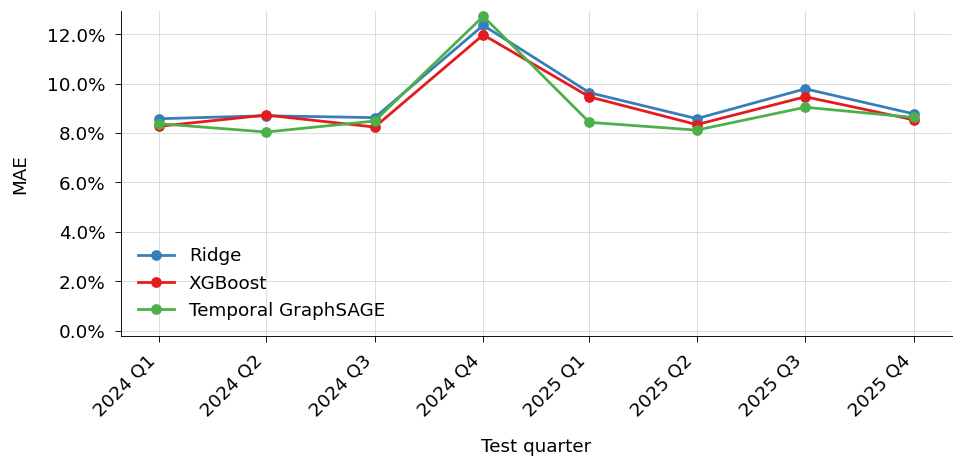

In [6]:
figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
for model in model_order:
    rows = quarterly_performance.loc[quarterly_performance['model'].eq(model)]
    axis.plot(rows['report_period'], rows['mae'], marker='o',
              color=model_colors[model], label=model)
axis.set_xlabel('Test quarter')
axis.set_ylabel('MAE')
axis.set_xticks(periods)
axis.set_xticklabels(labels, rotation=45, ha='right')
axis.set_ylim(bottom=-0.002)
axis.yaxis.set_major_formatter(PercentFormatter(1.0))
axis.legend(frameon=False)
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / '04_08_quarterly_test_mae_finalists.pdf')
plt.show()

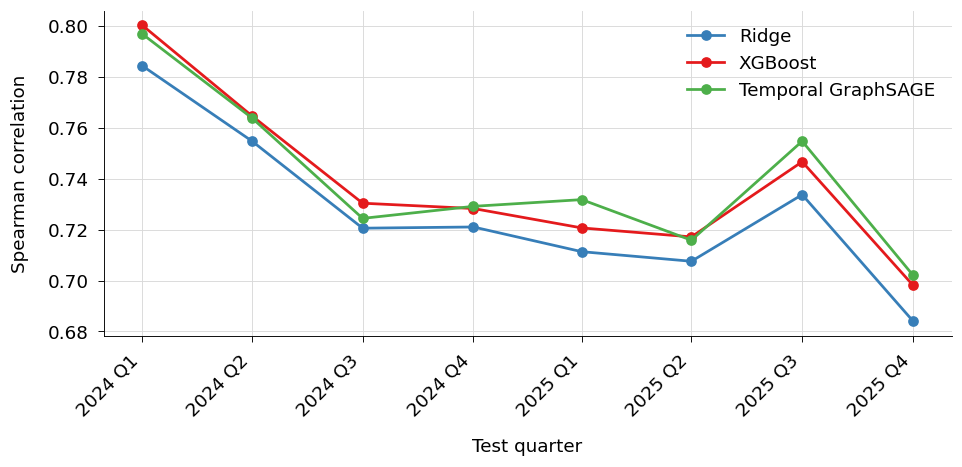

In [7]:
figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
for model in model_order:
    rows = quarterly_performance.loc[quarterly_performance['model'].eq(model)]
    axis.plot(rows['report_period'], rows['spearman'], marker='o',
              color=model_colors[model], label=model)
axis.set_xlabel('Test quarter')
axis.set_ylabel('Spearman correlation')
axis.set_xticks(periods)
axis.set_xticklabels(labels, rotation=45, ha='right')
axis.legend(frameon=False)
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / '04_08_quarterly_test_spearman_finalists.pdf')
plt.show()